# **CHOCOLATE SALES**

**PROBLEM STATEMENT:**


Chocolate companies generate large amounts of sales data through daily transactions. The aim is to analyze the chocolate sales dataset to understand product performance, country-wise sales, and shipment patterns in order to gain useful insights about overall sales trends.


**OBJECTIVE:**



* Understand the structure and variables present in the chocolate sales dataset.
* Perform data cleaning to handle any missing values, duplicates, or inconsistencies in the data.
* Conduct exploratory data analysis (EDA) to identify sales trends, product performance, and country-wise sales patterns.
* Summarize key insights that can help understand product demand, salesperson performance, and overall chocolate sales performance.


In [ ]:
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


**LOAD LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**LOAD DATA**

In [ ]:
df=pd.read_csv("/content/Chocolate Sales (2).csv")

# Check unique values and their counts in the raw 'Amount' column
print("Unique values in raw 'Amount' column:", df['Amount'].nunique())
print("Value counts in raw 'Amount' column:\n", df['Amount'].value_counts().head())


Unique values in raw 'Amount' column: 3013
Value counts in raw 'Amount' column:
 Amount
$2,317.00    5
$7,714.00    4
$3,577.00    4
$5,691.00    4
$3,472.00    4
Name: count, dtype: int64


**UNDERSTAND VARIABLES**

In [ ]:
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


The dataset was explored using functions like head(), info(), and describe() to understand its structure, data types, and statistical summary.

**BASIC CHECK**

In [ ]:
df.isnull().sum()
df.duplicated().sum()
df.nunique()

,0
Sales Person,25
Country,6
Product,22
Date,504
Amount,3013
Boxes Shipped,507


The dataset was further checked for missing values, duplicate records, and unique values using functions such as isnull().sum(), duplicated().sum(), and nunique() to ensure data quality before performing further analysis

**DATA CLEANING**

The dataset was checked for missing values and duplicate rows. Missing values were handled and duplicate records were removed to make the dataset ready for further analysis.


In [ ]:
# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Fill missing values for numeric columns with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill missing values for categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Clean 'Amount' column and convert to numeric
if 'Amount' in df.columns:
    # Remove $ and commas, then convert to numeric
    df['Amount'] = df['Amount'].astype(str).str.replace('[$,]', '', regex=True).astype(float)

# Convert 'Date' column to datetime
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

# Final shape of dataset
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (3282, 6)


**DATA WRAPPING**

Data wrangling is the process of preparing and transforming raw data into a clean and useful format for analysis. It helps improve the quality of the dataset and makes the analysis more accurate

In [ ]:
#Drop columns
df = df.drop(columns=['Sales Person'])

In [ ]:
#Rename Columns
df = df.rename(columns={'Sales Person':'Sales_Person'})

**EDA DATA VISUALIZATION**

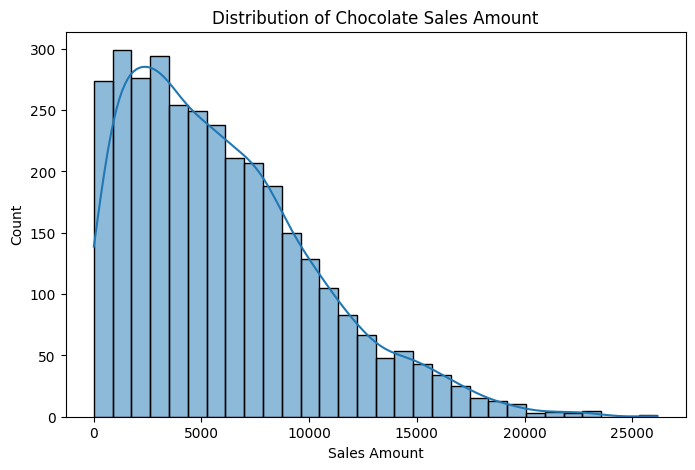

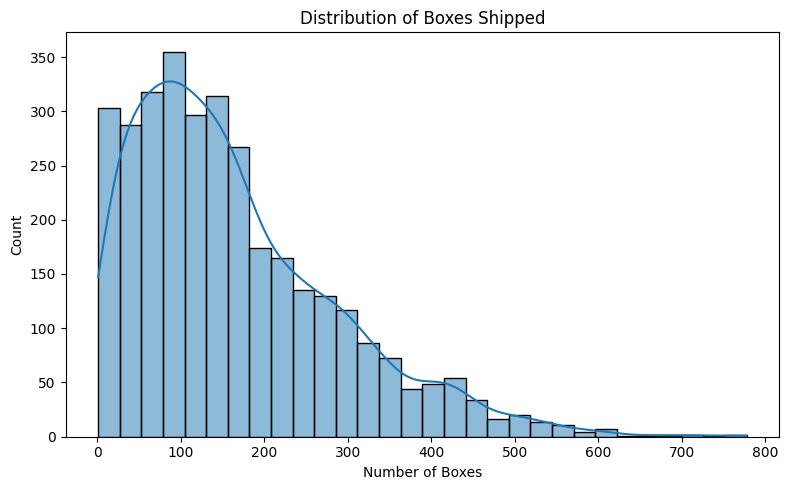

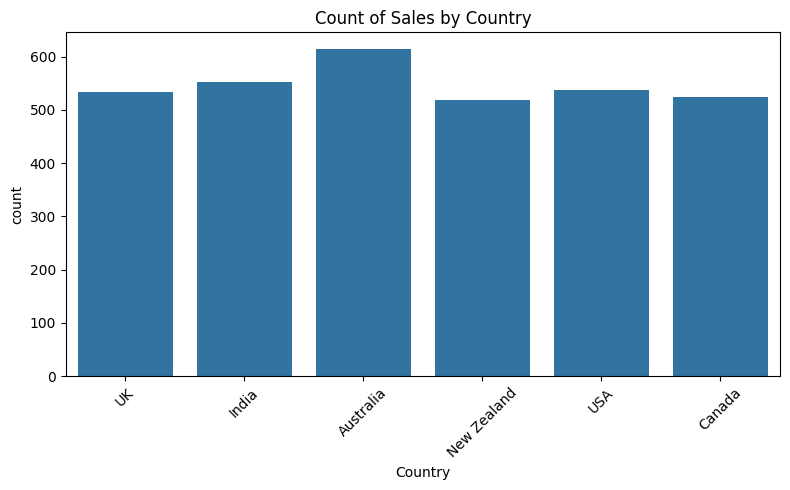

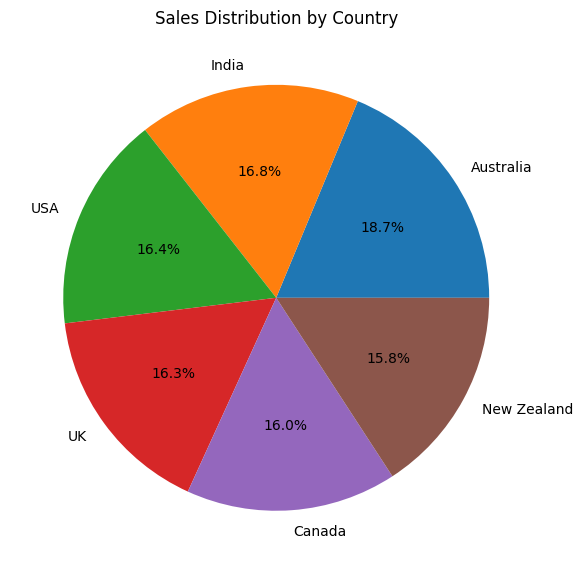

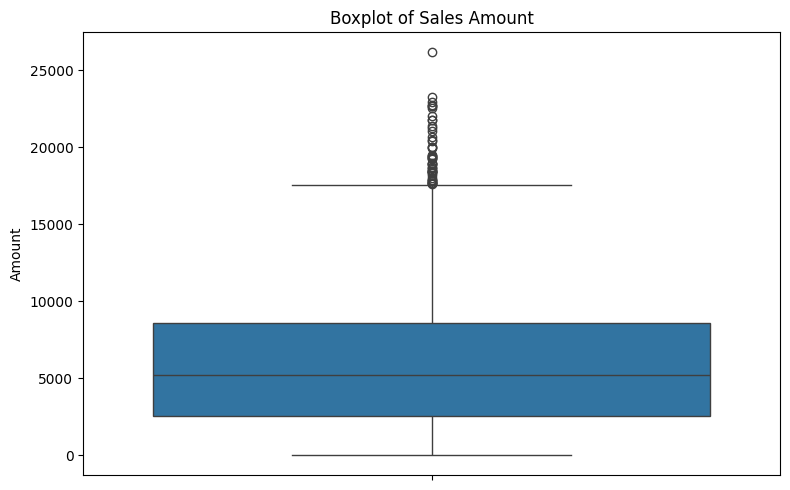

In [ ]:
# 1. Univariate Analysis

# Histogram – Sales Amount
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title("Distribution of Chocolate Sales Amount")
plt.xlabel("Sales Amount")
plt.show()


# Histogram – Boxes Shipped
plt.figure(figsize=(8,5))
sns.histplot(df['Boxes Shipped'], bins=30, kde=True)
plt.title("Distribution of Boxes Shipped")
plt.xlabel("Number of Boxes")
plt.tight_layout()
plt.show()


# Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x='Country', data=df)
plt.title("Count of Sales by Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Pie Chart
plt.figure(figsize=(6,6))
df['Country'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Sales Distribution by Country")
plt.ylabel("")
plt.tight_layout()
plt.show()


# Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Amount'])
plt.title("Boxplot of Sales Amount")
plt.tight_layout()
plt.show()

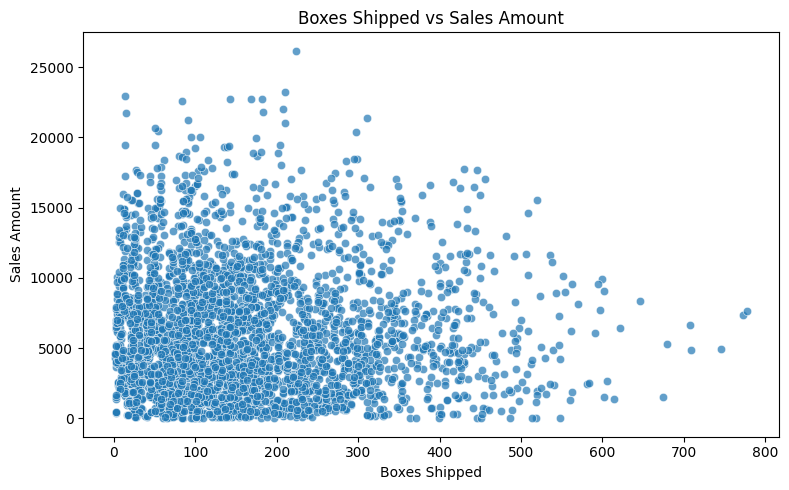

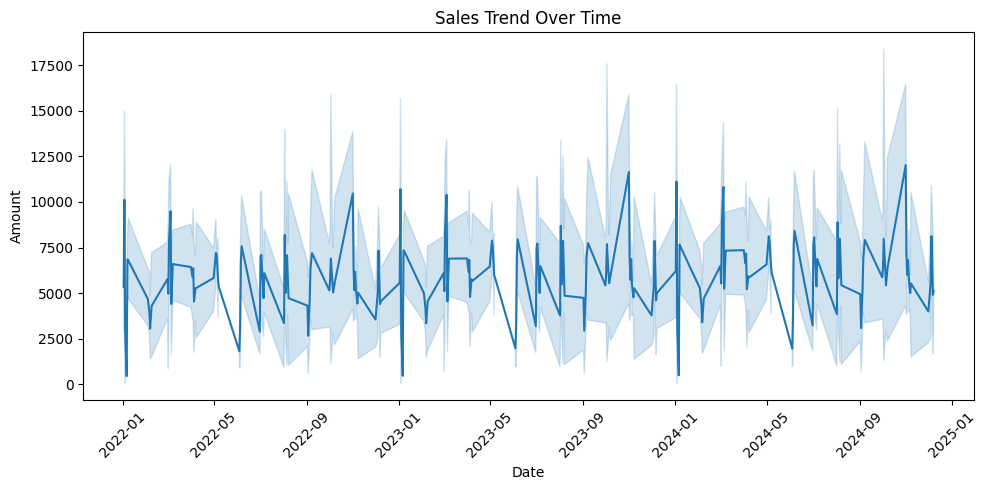

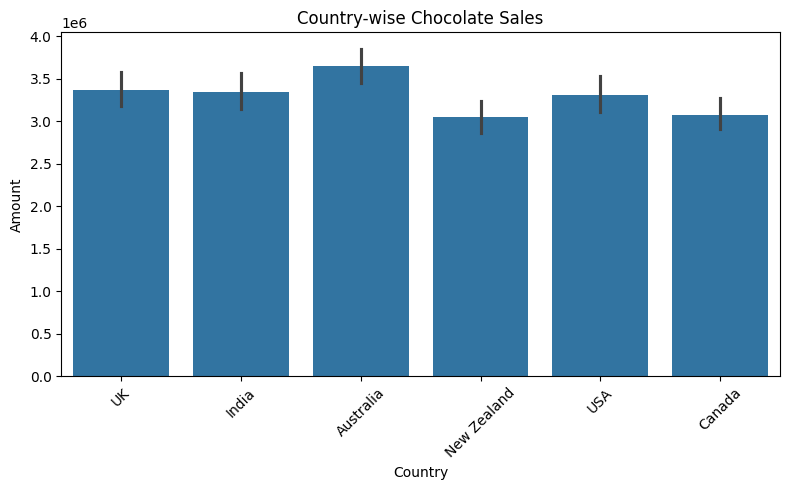

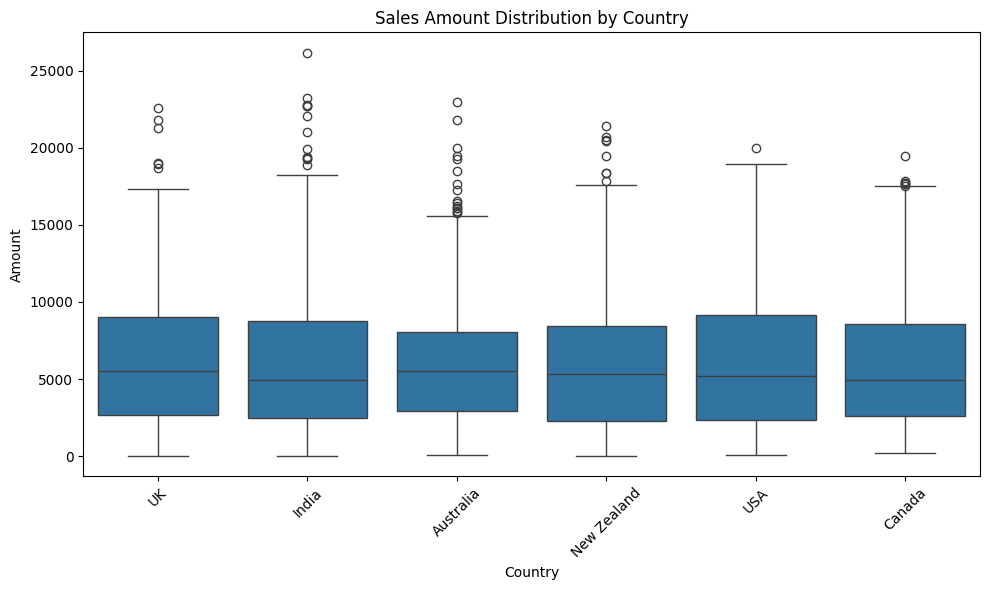

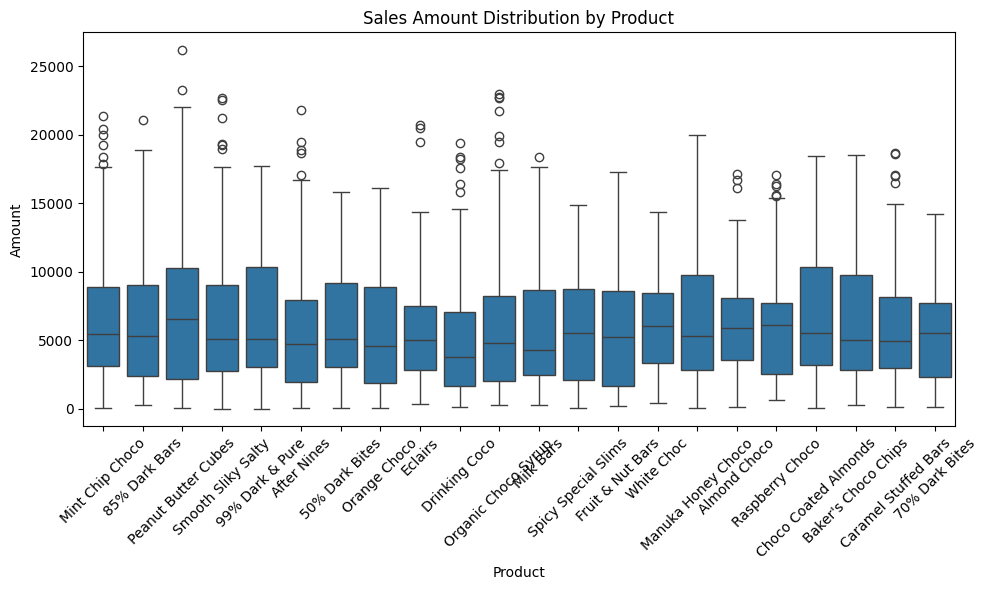

In [ ]:
# 2. Bivariate Analysis

# Scatterplot of Amount vs Boxes Shipped
plt.figure(figsize=(8,5))
sns.scatterplot(x='Boxes Shipped', y='Amount', data=df, alpha=0.7)
plt.title("Boxes Shipped vs Sales Amount")
plt.xlabel("Boxes Shipped")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()


# Line Plot (Sales Trend Over Time)
if 'Date' in df.columns:
    plt.figure(figsize=(10,5))
    sns.lineplot(x='Date', y='Amount', data=df)
    plt.title("Sales Trend Over Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Bar Plot (Country vs Sales Amount)
plt.figure(figsize=(8,5))
sns.barplot(x='Country', y='Amount', data=df, estimator=sum)
plt.title("Country-wise Chocolate Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Boxplot of Amount by Country
if 'Country' in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='Country', y='Amount', data=df)
    plt.title("Sales Amount Distribution by Country")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Boxplot of Amount by Product
if 'Product' in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='Product', y='Amount', data=df)
    plt.title("Sales Amount Distribution by Product")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

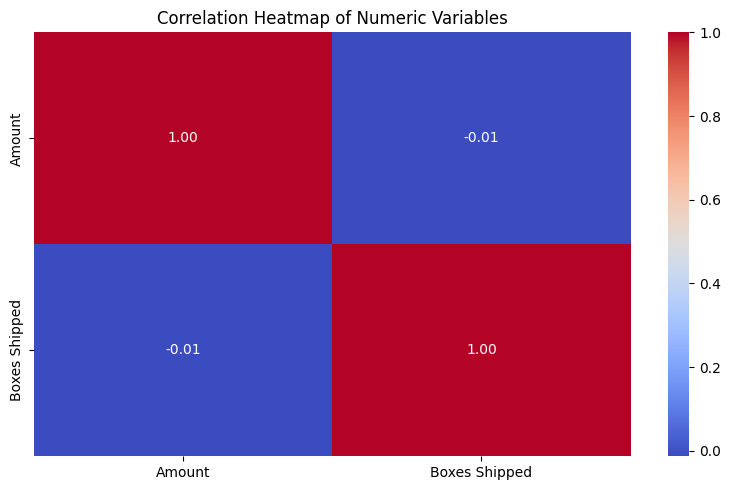

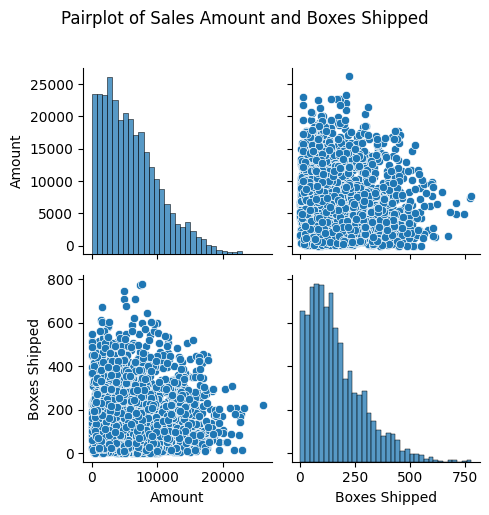

In [ ]:
# 3. Multivariate Analysis

# Select numeric columns
numeric_df = df.select_dtypes(include=['float64','int64'])

# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


# Pairplot
sns.pairplot(df[['Amount','Boxes Shipped']].dropna())
plt.suptitle("Pairplot of Sales Amount and Boxes Shipped", y=1.02)
plt.tight_layout()
plt.show()

**INSIGHTS**



* The analysis shows that chocolate sales vary across different countries, indicating differences in market demand.
* Some chocolate products generate higher sales compared to others, suggesting higher customer preference for those products.
* Sales performance differs among salespersons, with some contributing more to total sales.
* A positive relationship is observed between the number of boxes shipped and the sales amount, indicating that higher shipments generally result in higher sales.


**MODEL TRAINING**

In [ ]:
#Import ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Define features and target
X = df[['Boxes Shipped']]   # feature
y = df['Amount']            # target

In [ ]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Make predictions
y_pred = model.predict(X_test)

In [ ]:
#Evaluate the model
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: -0.003026935822416421
Mean Squared Error: 16879095.21157168


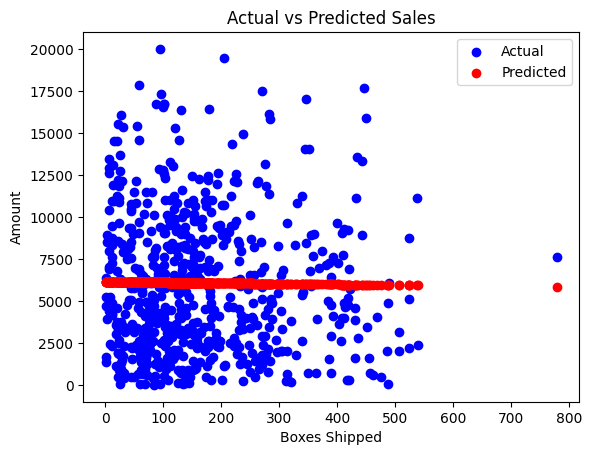

In [ ]:
#Visualize Prediction vs Actual
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Boxes Shipped")
plt.ylabel("Amount")
plt.legend()

plt.show()

**CONCLUSION**

The chocolate sales dataset was loaded and analyzed to understand its structure and key variables such as Country, Product, Amount, and Boxes Shipped. Data cleaning was performed by handling missing values and removing duplicates to improve data quality. Various visualizations such as histograms, bar charts, scatter plots, box plots, and heatmaps were used to explore sales patterns and relationships between variables. Finally, a Linear Regression machine learning model was applied to predict the sales amount based on the number of boxes shipped, and the model performance was evaluated using R² Score and Mean Squared Error. Overall, the analysis provides useful insights into chocolate sales performance across different countries and products.
